In [1]:
# Import Libraries and Connect to AWS S3
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import s3fs
fs = s3fs.S3FileSystem(anon=True)
import matplotlib.pyplot as plt
import re

In [2]:
# Load the Slurm Log as a Pandas Dataframe
df_slurm = pd.read_csv('s3://mit-supercloud-dataset/datacenter-challenge/202201/slurm-log.csv')
print(df_slurm.shape)

(395914, 29)


In [3]:
# Check how many jobs are in the dataset, and how many requested GPU's
scheduler_log_job_ids = df_slurm.id_job.unique()
gpu_idx = df_slurm.tres_req.apply(lambda x:str(x).find('1001')>0 or str(x).find('1002')>0)
scheduler_log_job_ids_gpu = np.unique(df_slurm[gpu_idx].id_job.values)
print('There are {} jobs in the scheduler log, of which {} requested GPUs.'.format(scheduler_log_job_ids.shape[0], scheduler_log_job_ids_gpu.shape[0]))

There are 395914 jobs in the scheduler log, of which 98176 requested GPUs.


In [4]:
# Take a look at the table structure
df_slurm.head(2)

,id_job,id_array_job,id_array_task,id_user,kill_requid,nodes_alloc,nodelist,cpus_req,derived_ec,exit_code,gres_used,array_max_tasks,array_task_pending,constraints,flags,mem_req,partition,priority,state,timelimit,time_submit,time_eligible,time_start,time_end,time_suspended,track_steps,tres_alloc,tres_req,job_type
0,82691694838059,38873353215144,2504,42770088536256,61026541062099,1,['r9189566-n911952'],20,0,0,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10237,3,4294967295,1609535703,1609535704,1609806297,1609806605,0,0,"1=20,2=170000,4=1,5=20","1=20,2=170000,4=1,5=20",OTHER
1,3434806870797,38873353215144,2523,42770088536256,61026541062099,1,['r9189566-n911952'],20,0,0,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10237,3,4294967295,1609535703,1609535704,1609806607,1609807004,0,0,"1=20,2=170000,4=1,5=20","1=20,2=170000,4=1,5=20",OTHER


#
# Checking value counts for interesting columns
#### See Data Dictionary for full list of columns

In [5]:
# Final job state
#   3 = job completed
#   4 = job cancelled
#   5 = job failed (Crashed)
#   6 = job failed (Timeout)
#   11 = job failed (Out of Memory)
#   7 = node failed

df_slurm['state'].value_counts()

state
3       309037
4        53980
5        21349
6         7089
11        4414
7           44
1024         1
Name: count, dtype: int64

In [6]:
# Number of CPUs/cores requested for a job
df_slurm['cpus_req'].value_counts().head(10)

cpus_req
1     170323
4      66540
8      41792
20     37808
10     14571
2      12822
40     11390
16      5538
5       5209
6       4787
Name: count, dtype: int64

In [7]:
# Number of nodes allocated for a job
df_slurm['nodes_alloc'].value_counts().head(10)

nodes_alloc
1     389353
2       2870
4        982
3        904
8        623
6        279
5        251
7        221
16       114
9         48
Name: count, dtype: int64

In [8]:
# Exit Code
df_slurm['exit_code'].value_counts().head(10)

exit_code
0        370150
256       15496
253        4414
35072      3004
33280       711
35584       620
34304       429
32512       294
512         258
9           130
Name: count, dtype: int64

In [9]:
# Derived Exit Code
df_slurm['derived_ec'].value_counts().head(10)

derived_ec
0        395106
11          351
9           161
256         148
58880        36
33280        26
253          26
35584        16
13           13
1792         11
Name: count, dtype: int64

In [10]:
# Amount of Memory requested for a job
df_slurm['mem_req'].value_counts().head(10)

mem_req
9223372036854784308    176752
9223372036854779808     69275
9223372036854777708     29110
9223372036854779608     27155
9223372036854784000     15983
9223372036854780808      8611
10240                    6748
5120                     6619
20480                    5772
9223372036854776208      5620
Name: count, dtype: int64

In [11]:
# Job Type
df_slurm['job_type'].value_counts()

job_type
OTHER                266622
LLSUB:BATCH           96347
LLMAPREDUCE:MAP       25844
LLSUB:INTERACTIVE      7101
Name: count, dtype: int64

In [13]:
# Trackable Resources allocated to a job
df_slurm['tres_alloc'].value_counts().head(10)

tres_alloc
1=1,2=8500,4=1,5=1                           63126
1=4,2=15200,4=1,5=4                          26344
1=8,2=15200,4=1,5=8                          25439
1=20,2=170000,4=1,5=20,1002=1                15716
1=1,2=4000,4=1,5=1                           15074
1=48,2=192000,4=1,5=48                       13412
1=1,2=8192,4=1,5=1                           11757
1=40,2=340000,4=1,5=40,1002=2                10979
1=20,2=170000,4=1,5=20                       10061
1=1,2=8500,3=18446744073709551614,4=1,5=1     8106
Name: count, dtype: int64

In [14]:
# Type of processor on which job is executed
df_slurm['constraints'].value_counts()

constraints
xeon-g6         192481
\N              188499
xeon-g6&6248     14845
xeon-e5             60
opteron             26
xeon-p8              2
opteron&6274         1
Name: count, dtype: int64

In [16]:
# Number of GPU's used by a job (data is missing so need to create a new column for this later using Trackable Resources)
df_slurm['gres_used'].value_counts()

Series([], Name: count, dtype: int64)

In [17]:
# Additional Slurm flags specified
df_slurm['flags'].value_counts()

flags
4     252310
8     135717
2       7882
12         5
Name: count, dtype: int64

In [3]:
# Create new columns for job duration 
df_slurm['duration_seconds'] = df_slurm['time_end'] - df_slurm['time_start']
df_slurm['duration_minutes'] = df_slurm['duration_seconds'] / 60
df_slurm['duration_hours'] = df_slurm['duration_seconds'] / 3600
print(df_slurm[['time_start', 'time_end', 'duration_seconds', 'duration_minutes', 'duration_hours']].head(3))

   time_start    time_end  duration_seconds  duration_minutes  duration_hours
0  1609806297  1609806605               308          5.133333        0.085556
1  1609806607  1609807004               397          6.616667        0.110278
2  1609807004  1609807331               327          5.450000        0.090833


In [9]:
# Calculate percentage of jobs in the dataset that take longer than X hours

percentage = (df_slurm['duration_hours'] <= 1).mean() * 100
print(f"{percentage:.2f}% of jobs ran for 1 hour or less")
percentage = (df_slurm['duration_hours'] > 1).mean() * 100
print(f"{percentage:.2f}% of jobs ran for more than 1 hour")
percentage = (df_slurm['duration_hours'] > 2).mean() * 100
print(f"{percentage:.2f}% of jobs ran for more than 2 hours")
percentage = (df_slurm['duration_hours'] > 4).mean() * 100
print(f"{percentage:.2f}% of jobs ran for more than 4 hours")
percentage = (df_slurm['duration_hours'] > 8).mean() * 100
print(f"{percentage:.2f}% of jobs ran for more than 8 hours")
percentage = (df_slurm['duration_hours'] > 24).mean() * 100
print(f"{percentage:.2f}% of jobs ran for more than 24 hours")

56.04% of jobs ran for 1 hour or less
43.96% of jobs ran for more than 1 hour
32.65% of jobs ran for more than 2 hours
23.99% of jobs ran for more than 4 hours
14.50% of jobs ran for more than 8 hours
5.39% of jobs ran for more than 24 hours


# Distribution of Job Durations
### Excluding the jobs that ran for over 24 hours for better visualization

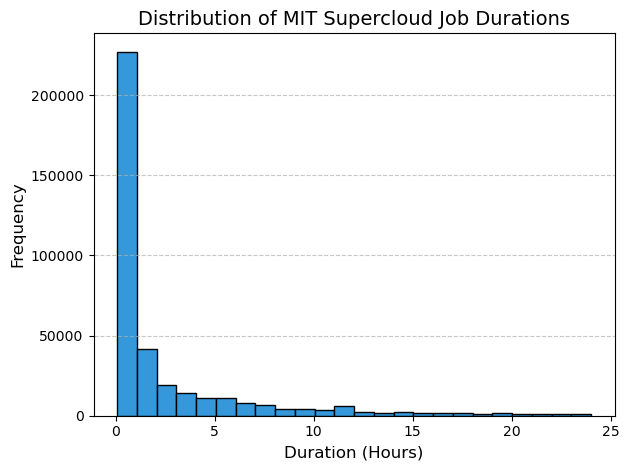

In [10]:
df_subset = df_slurm[df_slurm['duration_hours'] <= 24].copy()
plt.hist(df_subset['duration_hours'], bins=24, color='#3498db', edgecolor='black')
plt.title('Distribution of MIT Supercloud Job Durations', fontsize=14)
plt.xlabel('Duration (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('job_duration_histogram.png')

#
# Looking at Subset: Jobs that ran for <1 Hour

In [11]:
# Job State value counts
jobs_under_1hr = df_slurm[df_slurm['duration_hours'] < 1]['state'].value_counts()
jobs_under_1hr

state
3     180305
4      26936
5      12736
11      1811
6         57
7          6
Name: count, dtype: int64

In [12]:
# Looking at success/failure percentages in the subset
success = jobs_under_1hr.iloc[0]
failure = jobs_under_1hr.iloc[2:].sum()
cancelled = jobs_under_1hr.iloc[1]
total = jobs_under_1hr.sum()

fail_percent = (failure / total) * 100
cancelled_percent = (cancelled / total) * 100
success_percent = (success / total) * 100

print(f"{fail_percent:.2f}% of jobs that ran for less than 1 hour failed. {failure} total failures.")
print(f"{cancelled_percent:.2f}% of jobs that ran for less than 1 hour were cancelled by the user.")
print(f"{success_percent:.2f}% of jobs that ran for less than 1 hour were completed successfully.")

6.59% of jobs that ran for less than 1 hour failed. 14610 total failures.
12.14% of jobs that ran for less than 1 hour were cancelled by the user.
81.27% of jobs that ran for less than 1 hour were completed successfully.


In [16]:
# Finding the minimum job duration
min_val = df_slurm['duration_minutes'].min()
print("The minimum job duration of the entire MIT Supercloud dataset is " + str(min_val) + " minutes")

The minimum job duration of the entire MIT Supercloud dataset is 5.0 minutes


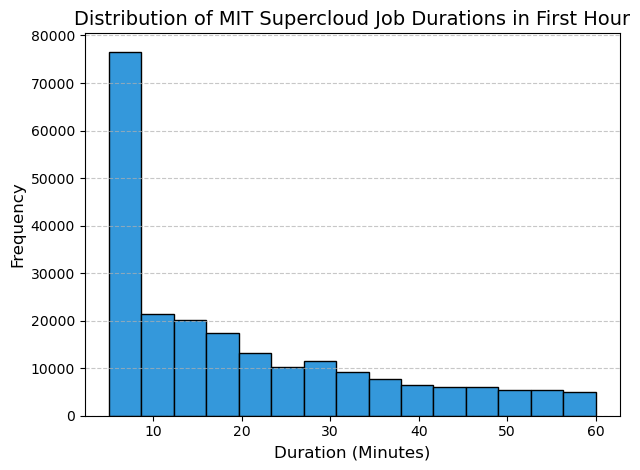

In [13]:
# Looking at distribution of jobs in the first hour
# No jobs had a duration of less than 5 minutes (This is the "Ramp Up" time) 

df_subset = df_slurm[df_slurm['duration_hours'] <= 1].copy()
plt.hist(df_subset['duration_minutes'], bins=15, color='#3498db', edgecolor='black')
plt.title('Distribution of MIT Supercloud Job Durations in First Hour', fontsize=14)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('job_duration_histogram.png')

##
## Looking at Subset: Jobs that ran for >1 Hour

In [28]:
# Job State value counts
jobs_1hr = df_slurm[df_slurm['duration_hours'] > 1]['state'].value_counts()
jobs_1hr

state
3       128712
4        27044
5         8610
6         7032
11        2602
7           38
1024         1
Name: count, dtype: int64

In [29]:
# Looking at success/failure percentages in the subset
success = jobs_1hr.iloc[0]
failure = jobs_1hr.iloc[2:].sum()
cancelled = jobs_1hr.iloc[1]
total = jobs_1hr.sum()

fail_percent = (failure / total) * 100
cancelled_percent = (cancelled / total) * 100
success_percent = (success / total) * 100

print(f"{fail_percent:.2f}% of jobs that ran for more than 1 hour failed. {failure} total failures.")
print(f"{cancelled_percent:.2f}% of jobs that ran for more than 1 hour were cancelled by the user.")
print(f"{success_percent:.2f}% of jobs that ran for more than 1 hour were completed successfully.")

10.51% of jobs that ran for more than 1 hour failed. 18283 total failures.
15.54% of jobs that ran for more than 1 hour were cancelled by the user.
73.96% of jobs that ran for more than 1 hour were completed successfully.


##
## Looking at Subset: Jobs that ran for >2 Hours

In [4]:
# Job State value counts
jobs_2hr = df_slurm[df_slurm['duration_hours'] > 2]['state'].value_counts()
jobs_2hr

state
3       91055
4       22644
6        7021
5        6253
11       2261
7          38
1024        1
Name: count, dtype: int64

In [5]:
# Looking at success/failure percentages in the subset
success = jobs_2hr.iloc[0]
failure = jobs_2hr.iloc[2:].sum()
cancelled = jobs_2hr.iloc[1]
total = jobs_2hr.sum()

fail_percent = (failure / total) * 100
cancelled_percent = (cancelled / total) * 100
success_percent = (success / total) * 100

print(f"{fail_percent:.2f}% of jobs that ran for more than 2 hours failed. {failure} total failures.")
print(f"{cancelled_percent:.2f}% of jobs that ran for more than 2 hours were cancelled by the user.")
print(f"{success_percent:.2f}% of jobs that ran for more than 2 hours were completed successfully.")

12.05% of jobs that ran for more than 2 hours failed. 15574 total failures.
17.52% of jobs that ran for more than 2 hours were cancelled by the user.
70.44% of jobs that ran for more than 2 hours were completed successfully.


In [ ]:
# Seeing a trend of increasing job failure rates as job duration increases

##
## Looking at Subset: Jobs that ran for >4 Hours

In [17]:
# Job State value counts
jobs_4hr = df_slurm[df_slurm['duration_hours'] > 4]['state'].value_counts()
jobs_4hr

state
3       62700
4       18894
6        7016
5        4809
11       1514
7          37
1024        1
Name: count, dtype: int64

In [23]:
# Looking at success/failure percentages in the subset
success = jobs_4hr.iloc[0]
failure = jobs_4hr.iloc[2:].sum()
cancelled = jobs_4hr.iloc[1]
total = jobs_4hr.sum()

fail_percent = (failure / total) * 100
cancelled_percent = (cancelled / total) * 100
success_percent = (success / total) * 100

print(f"{fail_percent:.2f}% of jobs that ran for more than 4 hours failed. {failure} total failures.")
print(f"{cancelled_percent:.2f}% of jobs that ran for more than 4 hours were cancelled by the user.")
print(f"{success_percent:.2f}% of jobs that ran for more than 4 hours were completed successfully.")

14.09% of jobs that ran for more than 4 hours failed. 13377 total failures.
19.89% of jobs that ran for more than 4 hours were cancelled by the user.
66.02% of jobs that ran for more than 4 hours were completed successfully.


##
## Looking at Subset: Jobs that ran for >8 Hours

In [30]:
# Job State value counts
jobs_8hr = df_slurm[df_slurm['duration_hours'] > 8]['state'].value_counts()
jobs_8hr

state
3       32601
4       14439
6        6083
5        3259
11        996
7          37
1024        1
Name: count, dtype: int64

In [31]:
# Looking at success/failure percentages in the subset
success = jobs_8hr.iloc[0]
failure = jobs_8hr.iloc[2:].sum()
cancelled = jobs_8hr.iloc[1]
total = jobs_8hr.sum()

fail_percent = (failure / total) * 100
cancelled_percent = (cancelled / total) * 100
success_percent = (success / total) * 100

print(f"{fail_percent:.2f}% of jobs that ran for more than 8 hours failed. {failure} total failures.")
print(f"{cancelled_percent:.2f}% of jobs that ran for more than 8 hours were cancelled by the user.")
print(f"{success_percent:.2f}% of jobs that ran for more than 8 hours were completed successfully.")

18.07% of jobs that ran for more than 8 hours failed. 10376 total failures.
25.15% of jobs that ran for more than 8 hours were cancelled by the user.
56.78% of jobs that ran for more than 8 hours were completed successfully.


##
## Looking at Subset: Jobs that ran for >24 Hours

In [28]:
# Job State value counts
jobs_24hr = df_slurm[df_slurm['duration_hours'] > 24]['state'].value_counts()
jobs_24hr

state
3       10124
4        6818
6        2402
5        1394
11        549
7          32
1024        1
Name: count, dtype: int64

In [29]:
# Looking at success/failure percentages in the subset
success = jobs_24hr.iloc[0]
failure = jobs_24hr.iloc[2:].sum()
cancelled = jobs_24hr.iloc[1]
total = jobs_24hr.sum()

fail_percent = (failure / total) * 100
cancelled_percent = (cancelled / total) * 100
success_percent = (success / total) * 100

print(f"{fail_percent:.2f}% of jobs that ran for more than 24 hours failed. {failure} total failures.")
print(f"{cancelled_percent:.2f}% of jobs that ran for more than 24 hours were cancelled by the user.")
print(f"{success_percent:.2f}% of jobs that ran for more than 24 hours were completed successfully.")

20.53% of jobs that ran for more than 24 hours failed. 4378 total failures.
31.98% of jobs that ran for more than 24 hours were cancelled by the user.
47.49% of jobs that ran for more than 24 hours were completed successfully.


##
## DECISION: I will focus on the subset of jobs that ran for >2 hours for this project
#### I want to try to predict job failures for this subset because jobs that run for over 2 hours cost more electricity, and are more likely to fail
#### I think that the 15,000 failures in this subset will provide enough signal to train a robust model

In [6]:
# Creating a new subset of jobs that had a duration of over 2 hours
jobs_2hr_df = df_slurm[df_slurm['duration_hours'] > 2]

In [60]:
jobs_2hr_df['cpus_req'].value_counts().head(10)

cpus_req
1     55354
4     19455
20    14820
8      7947
40     5350
10     5008
2      4489
21     3372
16     2540
5      2476
Name: count, dtype: int64

In [35]:
jobs_2hr_df['nodes_alloc'].value_counts().head(10)

nodes_alloc
1     126532
2       1327
4        375
3        331
8        319
6        100
7         76
5         69
16        51
9         18
Name: count, dtype: int64

In [38]:
jobs_2hr_df['job_type'].value_counts()

job_type
OTHER                96468
LLSUB:BATCH          20631
LLMAPREDUCE:MAP       8463
LLSUB:INTERACTIVE     3711
Name: count, dtype: int64

In [39]:
jobs_2hr_df['constraints'].value_counts()

constraints
xeon-g6         65829
\N              55870
xeon-g6&6248     7521
xeon-e5            34
opteron            18
opteron&6274        1
Name: count, dtype: int64

In [7]:
# Calculating how many jobs in this subset were allocated GPU's to run their workload

scheduler_log_job_ids = jobs_2hr_df.id_job.unique()
gpu_idx = jobs_2hr_df.tres_alloc.apply(lambda x:str(x).find('1001')>0 or str(x).find('1002')>0)
scheduler_log_job_ids_gpu = np.unique(jobs_2hr_df[gpu_idx].id_job.values)
print("There are {} jobs in the 2 hour subset, of which {} were allocated GPU's.".format(scheduler_log_job_ids.shape[0], scheduler_log_job_ids_gpu.shape[0]))
percentage = scheduler_log_job_ids_gpu.shape[0] / scheduler_log_job_ids.shape[0]
print(f"{percentage:.2%} of jobs over 2 hours in duration were allocated GPU's.")

There are 129273 jobs in the 2 hour subset, of which 52416 were allocated GPU's.
40.55% of jobs over 2 hours in duration were allocated GPU's.


In [62]:
# checking the >4 hour subset just to see if the GPU allocation percentage is dramatically higher

jobs_4hr_df = df_slurm[df_slurm['duration_hours'] > 4]
scheduler_log_job_ids = jobs_4hr_df.id_job.unique()
gpu_idx = jobs_4hr_df.tres_alloc.apply(lambda x:str(x).find('1001')>0 or str(x).find('1002')>0)
scheduler_log_job_ids_gpu = np.unique(jobs_4hr_df[gpu_idx].id_job.values)
print('There are {} jobs in the 4 hour subset, of which {} were allocated GPUs.'.format(scheduler_log_job_ids.shape[0], scheduler_log_job_ids_gpu.shape[0]))
percentage = scheduler_log_job_ids_gpu.shape[0] / scheduler_log_job_ids.shape[0]
print(f"{percentage:.2%} of jobs over 4 hours in duration were allocated GPU's.")

There are 94971 jobs in the 4 hour subset, of which 37058 were allocated GPUs.
39.02% of jobs over 4 hours in duration were allocated GPU's.


#
# A Closer look at the 15k Failures in the "2 hour" subset

In [8]:
# Create new column for count of GPU's allocated for each job
def get_allocated_gpu_count(tres_str):
    tres_str = str(tres_str)
    mappings = dict(re.findall(r'(\d+)=(\d+)', tres_str))
    
    # Check MIT Specific IDs (1001 or 1002)
    for specific_id in ['1001', '1002']:
        if specific_id in mappings:
            return int(mappings[specific_id])
    return 0

jobs_2hr_df = jobs_2hr_df.copy()
jobs_2hr_df['gpus_alloc'] = jobs_2hr_df['tres_alloc'].apply(get_allocated_gpu_count)

# Testing with example string
example = "1=20,2=170000,4=1,5=20,1002=1"
print(f"Allocated GPUs: {get_allocated_gpu_count(example)}")

Allocated GPUs: 1


In [9]:
# Quick look at the updated subset
jobs_2hr_df.tail(3)

,id_job,id_array_job,id_array_task,id_user,kill_requid,nodes_alloc,nodelist,cpus_req,derived_ec,exit_code,gres_used,array_max_tasks,array_task_pending,constraints,flags,mem_req,partition,priority,state,timelimit,time_submit,time_eligible,time_start,time_end,time_suspended,track_steps,tres_alloc,tres_req,job_type,duration_seconds,duration_minutes,duration_hours,gpus_alloc
395690,57434154297081,16618712154521,4294967294,73955363208519,61026541062099,1,['r1485405-n386398'],1,0,0,NaN,0,0,xeon-g6,2,9223372036854784308,normal,110197,3,1440,1633070087,1633070087,1633070087,1633100460,0,0,"1=40,2=340000,4=1,5=40,1002=2","1=1,2=8500,4=1,5=1,1002=2",LLSUB:INTERACTIVE,30373,506.216667,8.436944,2
395693,83047631767459,16618712154521,4294967294,14663149136002,61026541062099,1,['r3879907-n440434'],8,0,0,NaN,0,0,\N,8,9223372036854785808,xeon-p8,10330,3,7200,1633071435,1633071435,1633071461,1633081026,0,0,"1=8,2=80000,4=1,5=8","1=8,2=80000,4=1,5=8",OTHER,9565,159.416667,2.656944,0
395696,23853116866333,16618712154521,4294967294,2932858130821,61026541062099,1,['r9192091-n43543'],15,0,35584,NaN,0,0,\N,8,9223372036854784308,normal,10099,5,525600,1633073216,1633073216,1633073240,1633095136,0,0,"1=15,2=127500,4=1,5=15,1002=1","1=15,2=127500,4=1,5=15,1002=1",OTHER,21896,364.933333,6.082222,1


In [10]:
jobs_2hr_df['gpus_alloc'].value_counts()

gpus_alloc
0     76857
1     42677
2      8656
4       810
8       102
16       89
14       31
3        18
12       15
6        14
5         2
7         2
Name: count, dtype: int64

In [73]:
jobs_2hr_df['state'].value_counts()

state
3       91055
4       22644
6        7021
5        6253
11       2261
7          38
1024        1
Name: count, dtype: int64

In [12]:
# Create a new subset of just the job failures for jobs with duration over 2 hours
jobs_2hr_df_fails = jobs_2hr_df[jobs_2hr_df['state'].isin({6, 5, 11, 7})]
print(jobs_2hr_df_fails.shape)

(15573, 33)


In [75]:
jobs_2hr_df_fails['state'].value_counts()

state
6     7021
5     6253
11    2261
7       38
Name: count, dtype: int64

In [76]:
jobs_2hr_df_fails['gpus_alloc'].value_counts()

gpus_alloc
0     7700
1     6007
2     1799
16      29
8       16
4        9
12       6
6        2
3        2
14       2
7        1
Name: count, dtype: int64

In [78]:
jobs_2hr_df_fails['nodes_alloc'].value_counts()

nodes_alloc
1     15336
8        96
2        45
4        30
3        17
5        16
6        12
7         8
16        7
11        2
9         2
14        1
24        1
Name: count, dtype: int64

In [13]:
# Finding the average and median duration of this subset
avg_duration = jobs_2hr_df_fails['duration_hours'].mean()
print("Average Job Duration for jobs that ran over 2 hours and failed (in hours) = " + str(avg_duration))
med_duration = jobs_2hr_df_fails['duration_hours'].median()
print("Median Job Duration for jobs that ran over 2 hours and failed (in hours) = " + str(med_duration))

Average Job Duration for jobs that ran over 2 hours and failed (in hours) = 23.59516137260358
Median Job Duration for jobs that ran over 2 hours and failed (in hours) = 12.00388888888889


In [14]:
# Compare to subset of all jobs that ran for >2 hours
avg_duration = jobs_2hr_df['duration_hours'].mean()
print("Average Job Duration for jobs that ran over 2 hours (in hours) = " + str(avg_duration))
med_duration = jobs_2hr_df['duration_hours'].median()
print("Median Job Duration for jobs that ran over 2 hours (in hours) = " + str(med_duration))

Average Job Duration for jobs that ran over 2 hours (in hours) = 17.9381854163927
Median Job Duration for jobs that ran over 2 hours (in hours) = 6.916388888888889


In [16]:
# Looking at duration of jobs that failed and had >1 GPU allocated
avg_duration = jobs_2hr_df_fails.loc[jobs_2hr_df_fails['gpus_alloc'] > 1, 'duration_hours'].mean()
print("Average Job Duration for jobs that ran over 2 hours with >1 GPU and failed (in hours) = " + str(avg_duration))
med_duration = jobs_2hr_df_fails.loc[jobs_2hr_df_fails['gpus_alloc'] > 1, 'duration_hours'].median()
print("Median Job Duration for jobs that ran over 2 hours with >1 GPU and failed (in hours) = " + str(med_duration))

Average Job Duration for jobs that ran over 2 hours with >1 GPU and failed (in hours) = 30.17160161367155
Median Job Duration for jobs that ran over 2 hours with >1 GPU and failed (in hours) = 21.511944444444445


In [17]:
# Looking at duration of jobs that failed and had >2 GPU's allocated
avg_duration = jobs_2hr_df_fails.loc[jobs_2hr_df_fails['gpus_alloc'] > 2, 'duration_hours'].mean()
print("Average Job Duration for jobs that ran over 2 hours with >2 GPU's and failed (in hours) = " + str(avg_duration))
med_duration = jobs_2hr_df_fails.loc[jobs_2hr_df_fails['gpus_alloc'] > 2, 'duration_hours'].median()
print("Median Job Duration for jobs that ran over 2 hours with >2 GPU's and failed (in hours) = " + str(med_duration))

Average Job Duration for jobs that ran over 2 hours with >2 GPU's and failed (in hours) = 79.05507877280266
Median Job Duration for jobs that ran over 2 hours with >2 GPU's and failed (in hours) = 48.00055555555556


In [18]:
# Looking at duration of jobs that failed and had >1 Nodes allocated
avg_duration = jobs_2hr_df_fails.loc[jobs_2hr_df_fails['nodes_alloc'] > 1, 'duration_hours'].mean()
print("Average Job Duration for jobs that ran over 2 hours with >1 Node and failed (in hours) = " + str(avg_duration))
med_duration = jobs_2hr_df_fails.loc[jobs_2hr_df_fails['nodes_alloc'] > 1, 'duration_hours'].median()
print("Median Job Duration for jobs that ran over 2 hours with >1 Node and failed (in hours) = " + str(med_duration))

Average Job Duration for jobs that ran over 2 hours with >1 Node and failed (in hours) = 36.61625058602907
Median Job Duration for jobs that ran over 2 hours with >1 Node and failed (in hours) = 11.990833333333333


# Distribution of Job Durations for the job failures in the subset
### Excluding jobs that ran for over 48 hours for better visualization

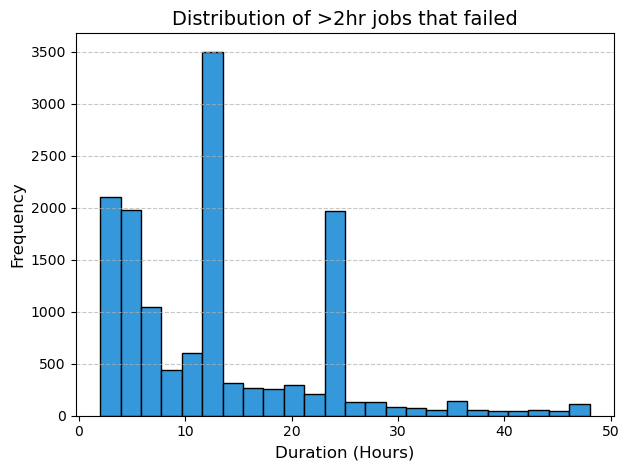

In [19]:
new_subset = jobs_2hr_df_fails[jobs_2hr_df_fails['duration_hours'] <= 48].copy()
plt.hist(new_subset['duration_hours'], bins=24, color='#3498db', edgecolor='black')
plt.title('Distribution of >2hr jobs that failed', fontsize=14)
plt.xlabel('Duration (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

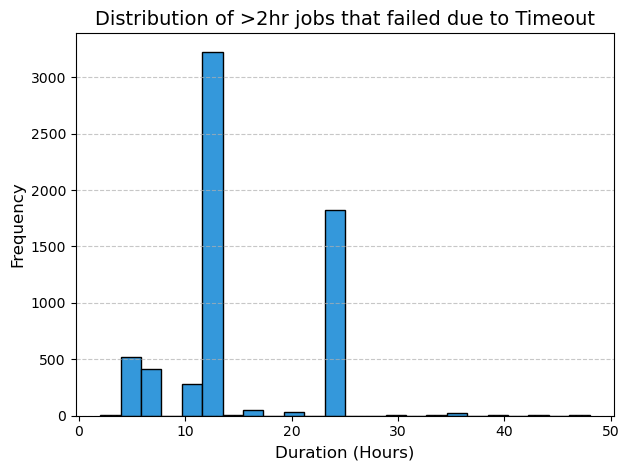

In [20]:
# Plot with just Timeout Failures
timeout_subset = new_subset[new_subset['state'] == 6].copy()
plt.hist(timeout_subset['duration_hours'], bins=24, color='#3498db', edgecolor='black')
plt.title('Distribution of >2hr jobs that failed due to Timeout', fontsize=14)
plt.xlabel('Duration (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

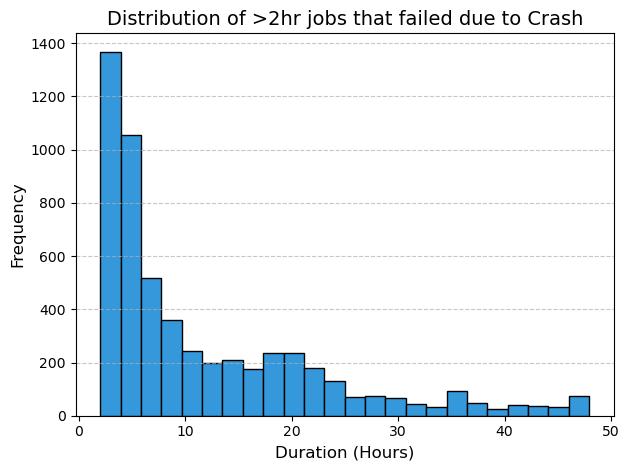

In [21]:
# Plot with just Crash Failures
crash_subset = new_subset[new_subset['state'] == 5].copy()
plt.hist(crash_subset['duration_hours'], bins=24, color='#3498db', edgecolor='black')
plt.title('Distribution of >2hr jobs that failed due to Crash', fontsize=14)
plt.xlabel('Duration (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

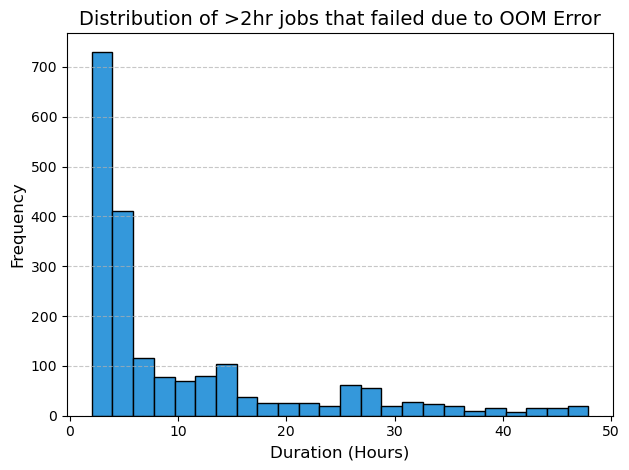

In [22]:
# Plot with just Out of Memory Failures
OOM_subset = new_subset[new_subset['state'] == 11].copy()
plt.hist(OOM_subset['duration_hours'], bins=24, color='#3498db', edgecolor='black')
plt.title('Distribution of >2hr jobs that failed due to OOM Error', fontsize=14)
plt.xlabel('Duration (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()